# Notebook 06 - Neural Networks for Speech Emotion Recognition

Three networks compared on the speech subset:

1. **MLP (ours)** - `minilearn.classifiers.MLPClassifier`, one hidden layer, 64 units, trained from scratch with backpropagation.
2. **MLP (sklearn)** - same shape, used as a sanity check on our implementation.
3. **Keras Dense NN** - the off-the-shelf deep learning model required by the project. Two hidden layers (128 and 64) with dropout regularization.

This notebook completes the supervised classification work and the MiniLearn library.

In [3]:
!pip install tensorflow
import tensorflow as tf
print(tf.__version__)

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.8 MB 8.9 MB/s eta 0:00:40
   ---------------------------------------- 1.1/350.8 MB 14.0 MB/s eta 0:00:25
   ---------------------------------------- 2.2/350.8 MB 19.7 MB/s eta 0:00:18
   ---------------------------------------- 3.6/350.8 MB 25.2 MB/s eta 0:00:14
    --------------------------------------- 4.7/350.8 MB 25.2 MB/s eta 0:00:14
    --------------------------------------- 5.6/350.8 MB 27.3 MB/s eta 0:00:13
    --------------------------------------- 5.9/350.8 MB 23.8 MB/s eta 0:00:15
    --------------------------------------- 7.0/350.8 MB 24.8 MB/s eta 0:00:14
    --------------------------------------- 8.1/350.8 MB 24.8 MB/s eta 0:00:14
   - -------------


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2.21.0


In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.classifiers import MLPClassifier
from minilearn.metrics import (accuracy_score, f1_score, confusion_matrix)

from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier as SkMLP

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
print(f"TensorFlow version: {tf.__version__}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
TensorFlow version: 2.21.0


In [5]:
feats = pd.read_csv(PROJECT_ROOT / "features" / "features.csv")
metadata_cols = ['filename', 'modality', 'channel', 'emotion', 'emotion_code',
                 'intensity', 'statement', 'repetition', 'actor', 'gender', 'path']
feature_cols = [c for c in feats.columns if c not in metadata_cols]

speech = feats[feats['channel'] == 'speech'].reset_index(drop=True)
X = speech[feature_cols].values
y = speech['emotion'].values

nan_mask = np.isnan(X).any(axis=1)
if nan_mask.any():
    X, y = X[~nan_mask], y[~nan_mask]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                          random_state=42, stratify=y)
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

# Keras needs integer labels
le = LabelEncoder().fit(y_tr)
y_tr_int = le.transform(y_tr)
y_te_int = le.transform(y_te)
n_classes = len(le.classes_)

print(f"Train: {X_tr.shape}, Test: {X_te.shape}")
print(f"Classes ({n_classes}): {list(le.classes_)}")

Train: (1155, 112), Test: (285, 112)
Classes (8): ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


## 1. Our MiniLearn MLP

One hidden layer with 64 units, ReLU activation, softmax output, trained with mini-batch SGD on cross-entropy loss. Implemented from scratch with backpropagation.

In [6]:
print("Training MiniLearn MLP ...")
ours = MLPClassifier(hidden_size=64, learning_rate=0.01,
                     max_iter=300, batch_size=32, C=1.0, random_state=42)
ours.fit(X_tr_s, y_tr)
y_pred_ours = ours.predict(X_te_s)

print(f"  Accuracy: {accuracy_score(y_te, y_pred_ours):.4f}")
print(f"  Macro F1: {f1_score(y_te, y_pred_ours, average='macro'):.4f}")
print(f"  Final training loss: {ours.loss_history_[-1]:.4f}")

Training MiniLearn MLP ...
  Accuracy: 0.6140
  Macro F1: 0.6001
  Final training loss: 0.1513


## 2. sklearn MLP - sanity check

In [7]:
print("Training sklearn MLP...")
sk_mlp = SkMLP(hidden_layer_sizes=(64,), max_iter=500,
               random_state=42).fit(X_tr_s, y_tr)
y_pred_sk = sk_mlp.predict(X_te_s)

print(f"  Accuracy: {accuracy_score(y_te, y_pred_sk):.4f}")
print(f"  Macro F1: {f1_score(y_te, y_pred_sk, average='macro'):.4f}")

Training sklearn MLP...
  Accuracy: 0.6246
  Macro F1: 0.6153


## 3. Keras Dense Neural Network — the off-the-shelf DL model

A deeper architecture than our MLP, with dropout for regularization:
Input (112) → Dense(128) → ReLU → Dropout(0.3)
→ Dense(64)  → ReLU → Dropout(0.3)
→ Dense(8)   → Softmax

Trained with Adam optimizer (adaptive learning rates), sparse categorical cross-entropy, validation split of 15% from the training set.

In [8]:
keras.utils.set_random_seed(42)

keras_model = keras.Sequential([
    layers.Input(shape=(X_tr_s.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax'),
])

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
keras_model.summary()

print("\nTraining...")
history = keras_model.fit(
    X_tr_s, y_tr_int,
    validation_split=0.15,
    epochs=80,
    batch_size=32,
    verbose=0,
)

test_loss, test_acc = keras_model.evaluate(X_te_s, y_te_int, verbose=0)
y_pred_keras_int = np.argmax(keras_model.predict(X_te_s, verbose=0), axis=1)
y_pred_keras = le.inverse_transform(y_pred_keras_int)

print(f"\nKeras test accuracy: {test_acc:.4f}")
print(f"Keras macro F1:      {f1_score(y_te, y_pred_keras, average='macro'):.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        14,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,240 (90.78 KB)

 Trainable params: 23,240 (90.78 KB)

 Non-trainable params: 0 (0.00 B)


Training...

Keras test accuracy: 0.6316
Keras macro F1:      0.6278


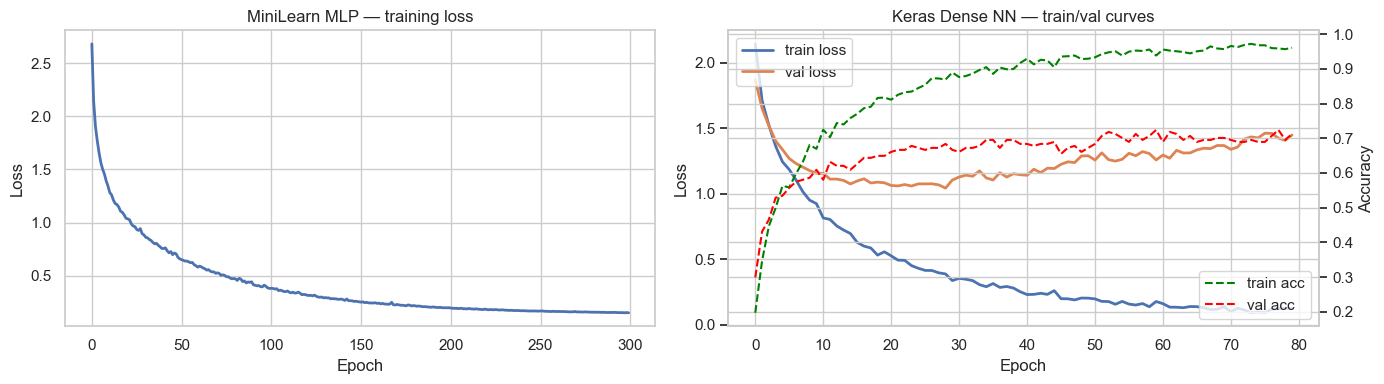

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ours.loss_history_, linewidth=2)
axes[0].set_title("MiniLearn MLP — training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

ax = axes[1]
ax.plot(history.history['loss'],     label='train loss', linewidth=2)
ax.plot(history.history['val_loss'], label='val loss',   linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax2 = ax.twinx()
ax2.plot(history.history['accuracy'],     '--', color='green', label='train acc')
ax2.plot(history.history['val_accuracy'], '--', color='red',   label='val acc')
ax2.set_ylabel("Accuracy")
ax.set_title("Keras Dense NN — train/val curves")
ax.legend(loc='upper left')
ax2.legend(loc='lower right')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "nn_training_curves.png", dpi=120)
plt.show()

In [10]:
nn_results = pd.DataFrame([
    {'model': 'MLP (ours, 1×64)',
     'accuracy': accuracy_score(y_te, y_pred_ours),
     'macro_f1': f1_score(y_te, y_pred_ours, average='macro')},
    {'model': 'MLP (sklearn, 1×64)',
     'accuracy': accuracy_score(y_te, y_pred_sk),
     'macro_f1': f1_score(y_te, y_pred_sk, average='macro')},
    {'model': 'Keras Dense (128→64)',
     'accuracy': float(test_acc),
     'macro_f1': f1_score(y_te, y_pred_keras, average='macro')},
])
print(nn_results.round(4).to_string(index=False))
nn_results.to_csv(PROJECT_ROOT / "features" / "nn_comparison.csv", index=False)

               model  accuracy  macro_f1
    MLP (ours, 1×64)    0.6140    0.6001
 MLP (sklearn, 1×64)    0.6246    0.6153
Keras Dense (128→64)    0.6316    0.6278


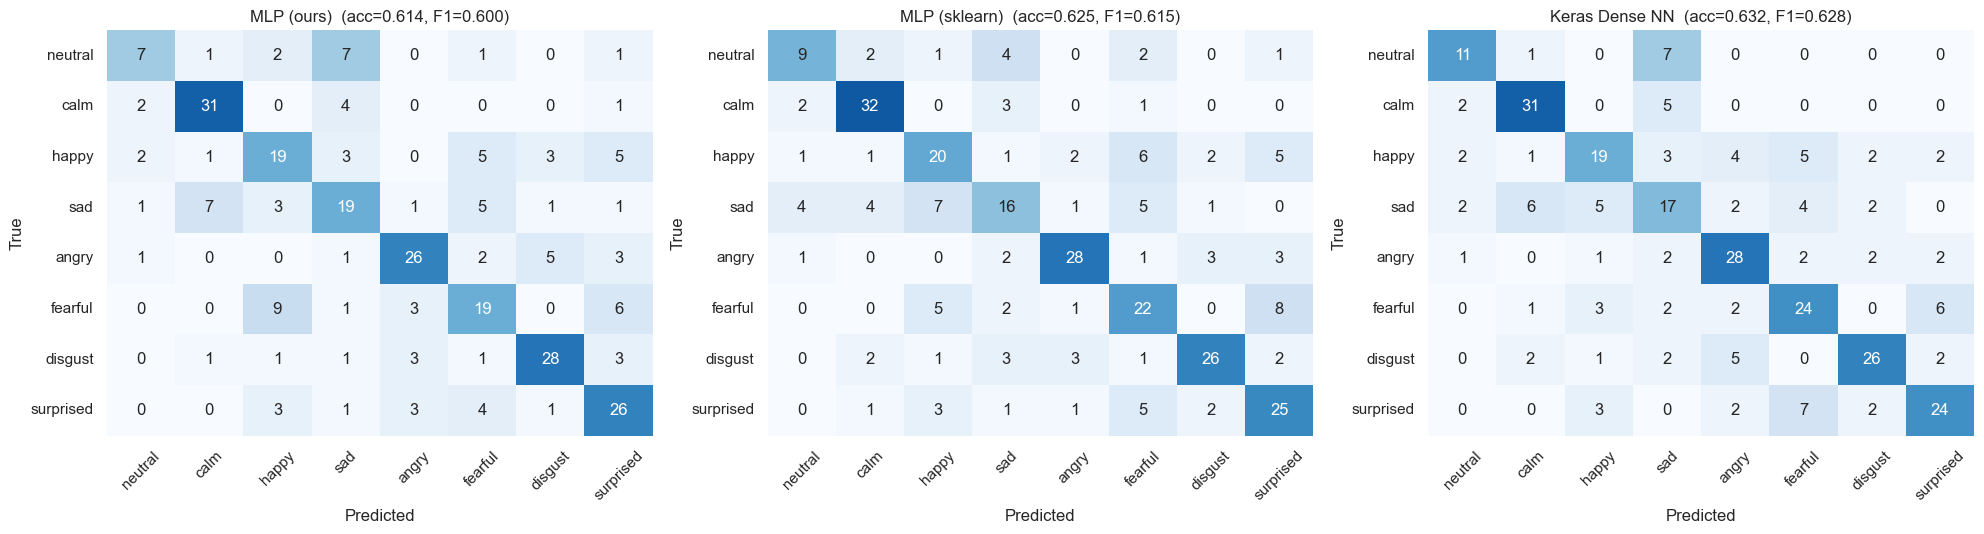

In [11]:
emotion_order = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
preds = {
    'MLP (ours)':         y_pred_ours,
    'MLP (sklearn)':      y_pred_sk,
    'Keras Dense NN':     y_pred_keras,
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
for ax, (name, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_te, y_pred, labels=emotion_order)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=emotion_order, yticklabels=emotion_order,
                vmin=0, vmax=1, ax=ax, cbar=False)
    acc = accuracy_score(y_te, y_pred)
    f1m = f1_score(y_te, y_pred, average='macro')
    ax.set_title(f"{name}  (acc={acc:.3f}, F1={f1m:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "nn_confusion_matrices.png", dpi=120)
plt.show()

## Findings

- **All three networks land at similar accuracy:** our MLP 0.614, sklearn MLP 0.625, Keras Dense NN 0.632. The Keras model wins by only ~2 points despite having more parameters and dropout.

- **Our MLP closely matches sklearn's** (within ~1 point of accuracy and F1). The small gap reflects optimizer differences, we use plain mini-batch SGD; sklearn uses Adam.

- **The Keras model overfits visibly.** The right curve shows training loss dropping toward 0.15 while validation loss *climbs* from ~1.1 to ~1.4 over 80 epochs, and training accuracy hits 95% while validation plateaus near 70%. Even with dropout=0.3 the model is memorizing training data. Early stopping or stronger regularization would help.

- **Neural networks do not dramatically beat classical models.** Notebook 04's best Logistic Regression was ~0.62, essentially the same as the Keras network. With hand-crafted MFCC features, most of the discriminative signal is linear, so deeper non-linear networks have little extra to learn.

- **Confusion patterns are consistent across all models.** `calm` is reliably classified (31–32 of ~36); `neutral` is repeatedly confused with `sad` (low-arousal cluster); `fearful` mixes with `happy`/`surprised`/`angry` (high-arousal cluster). These confusions are acoustic in origin, not model-specific.

- **To significantly exceed ~0.65 accuracy** we'd need richer features (pre-trained audio embeddings like wav2vec or HuBERT) or models that consume raw audio (1D-CNN, LSTM) directly. Hand-crafted features have hit their ceiling.